In [1]:
# Importing libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://drive.google.com/uc?id=1BQVc6MHjQFtDC9iP1isT_K4ojVe_Oil-')

In [3]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


---
OBSERVATIONS

1) Dataset consists of 240 rows, 6 feature and 1 target columns,

   -  Absolute Temperature (in K)
   -  Relative Luminosity (L/Lo)
   -  Relative Radius (R/Ro)
   -  Absolute Magnitude (Mv)
   -  Star Color
   -  Spectral Class
   -  Star Type (Target classes)

Here,

   - Lo = 3.828 x 10^26 Watts (Avg Luminosity of Sun)
   - Ro = 6.9551 x 10^8 m (Avg Radius of Sun)

2) Two categorical features (object type) which will need some kind of encoding,

   - Star Color
   - Spectral Class

3) It consists of some different features of stars. Information on the star type is given below,

   - 0 → Brown Dwarf
   - 1 → Red Dwarf
   - 2 → White Dwarf
   - 3 → Main Sequence
   - 4 → Supergiants
   - 5 → Hypergiants


In [5]:
# Creating a directory to save visualizations

folder_name = 'star_plots'
os.makedirs(folder_name, exist_ok=True)

def save_plot(filename):
    plt.savefig(os.path.join(folder_name, filename))


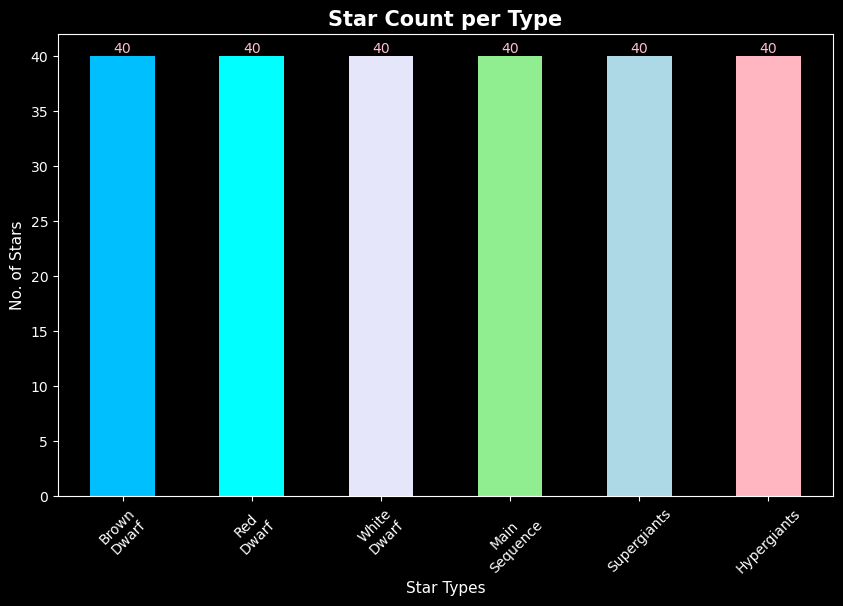

In [13]:
# Visualizing count of stars per type

labels = ['Brown\nDwarf', 'Red\nDwarf', 'White\nDwarf', 'Main\nSequence', 'Supergiants', 'Hypergiants']

plt.figure(figsize=(10,6))
plt.style.use('dark_background')

ax = df['Star type'].value_counts().plot(kind='bar', color = ['deepskyblue', 'cyan', 'lavender', 'lightgreen', 'lightblue', 'lightpink'])
ax.bar_label(ax.containers[0], color='pink')

plt.title('Star Count per Type', weight='bold', fontsize=15)
plt.ylabel('No. of Stars', fontsize = 11)
plt.xlabel('Star Types', fontsize = 11)
plt.xticks(ticks=[0,1,2,3,4,5], labels = labels, rotation=45)

save_plot('bar_plot_star_count.png')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22564\1803910805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['Star color'].value_counts().index,


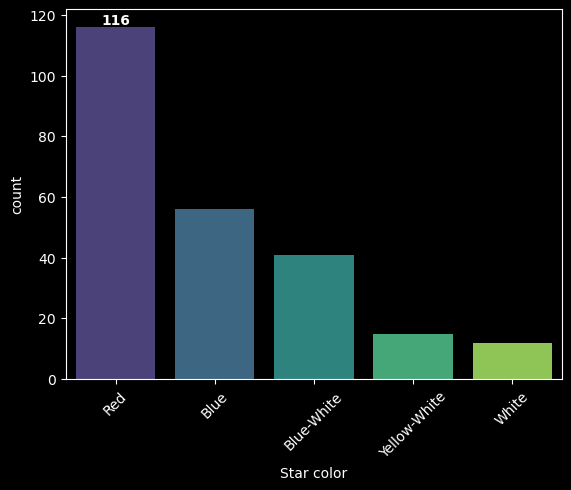

In [7]:
# Visualizing the Star colour

ax = sns.barplot(x=df['Star color'].value_counts().index, 
            y=df['Star color'].value_counts(), 
           palette='viridis'
           )
ax.bar_label(ax.containers[0], weight = 'bold')
plt.xticks(rotation=45)

save_plot('bar_plot_star_colour.png')
plt.show()

In [8]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


C:\Users\User\AppData\Local\Temp\ipykernel_22564\46968012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Star type'], y=df.iloc[:,i], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_22564\46968012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Star type'], y=df.iloc[:,i], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_22564\46968012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Star type'], y=df.iloc[:,i], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_22564\469680

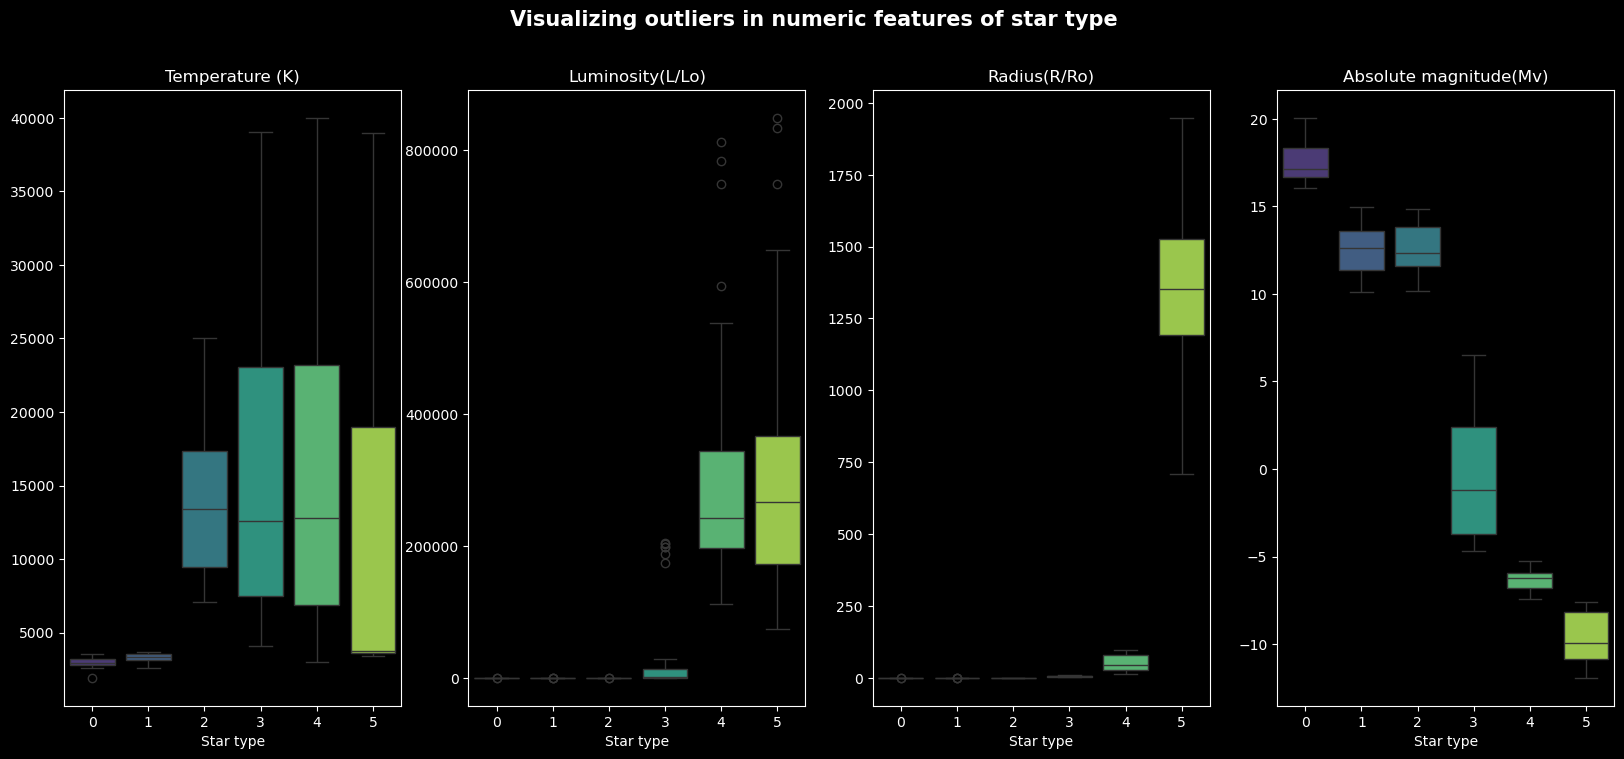

In [9]:
# Visualizing outliers in data

plt.figure(figsize=(20,8))
plt.suptitle('Visualizing outliers in numeric features of star type', fontsize = 15, weight='bold')

for i in range(4):
    plt.subplot(1,4,i+1)
    sns.boxplot(x=df['Star type'], y=df.iloc[:,i], palette='viridis')
    plt.title(df.columns[i])
    plt.ylabel('')

save_plot('boxplot_star_type.png')
plt.show()

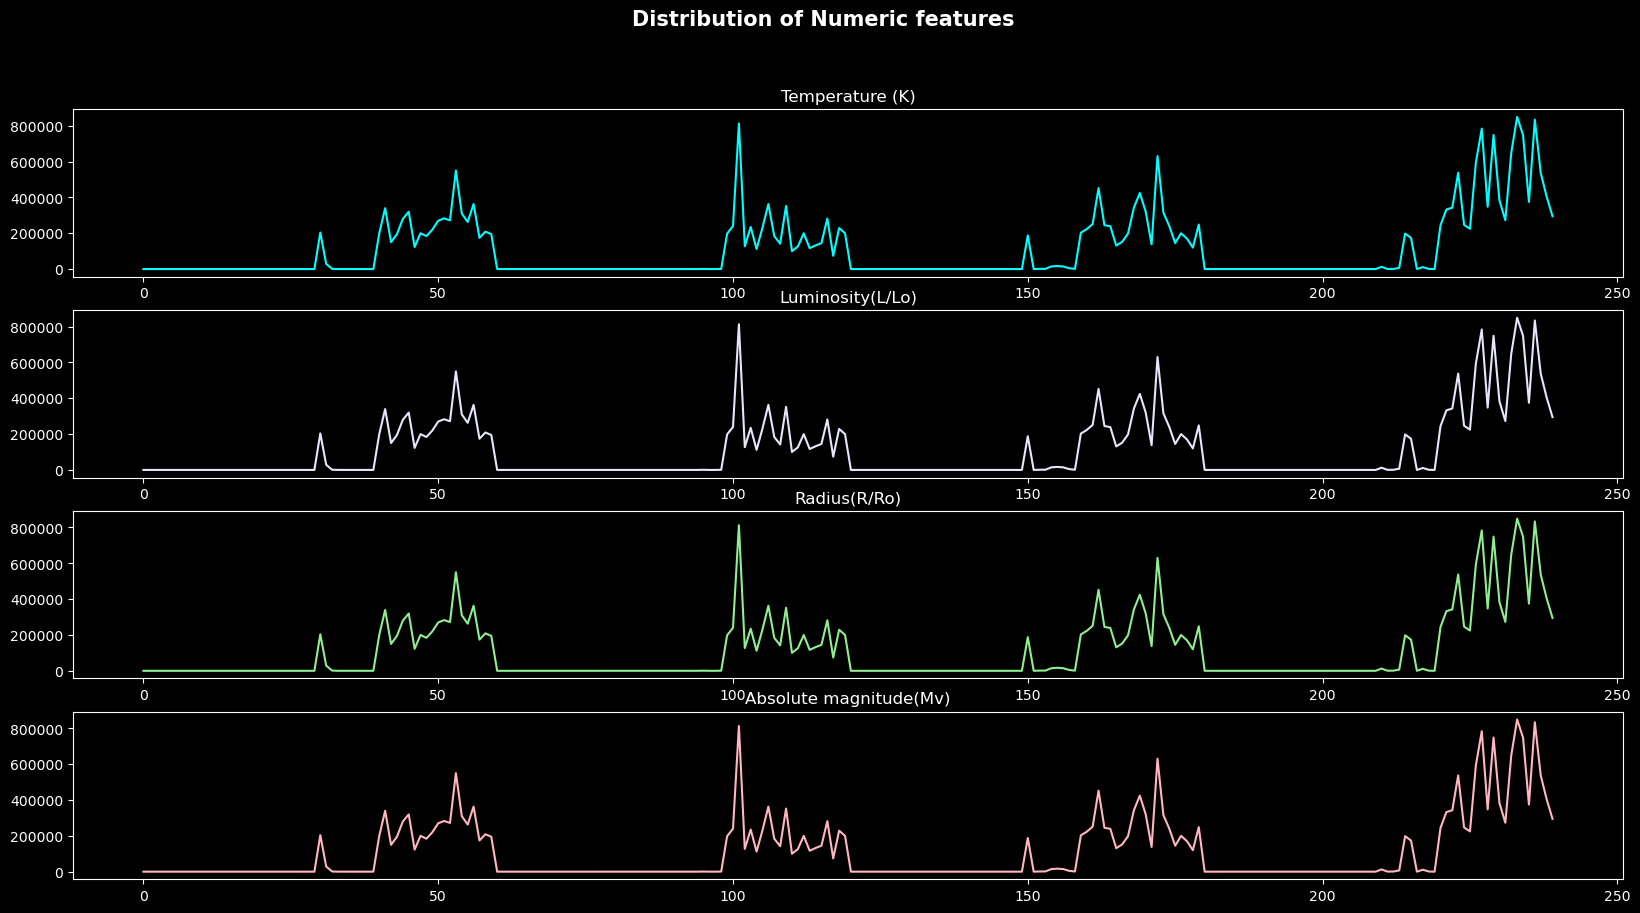

In [10]:
# Visualizing first 4 numerical columns

colors = ['cyan', 'lavender', 'lightgreen', 'lightpink']
plt.figure(figsize=[20,10])
plt.suptitle('Distribution of Numeric features', weight = 'bold', fontsize=15)

for i in range(4):
    plt.subplot(4,1,i+1)
    plt.plot(df.iloc[:,1], color=colors[i])
    plt.title(df.columns[i])

# plt.tight_layout()
save_plot('line_plot_numerical_cols.png')
plt.show()

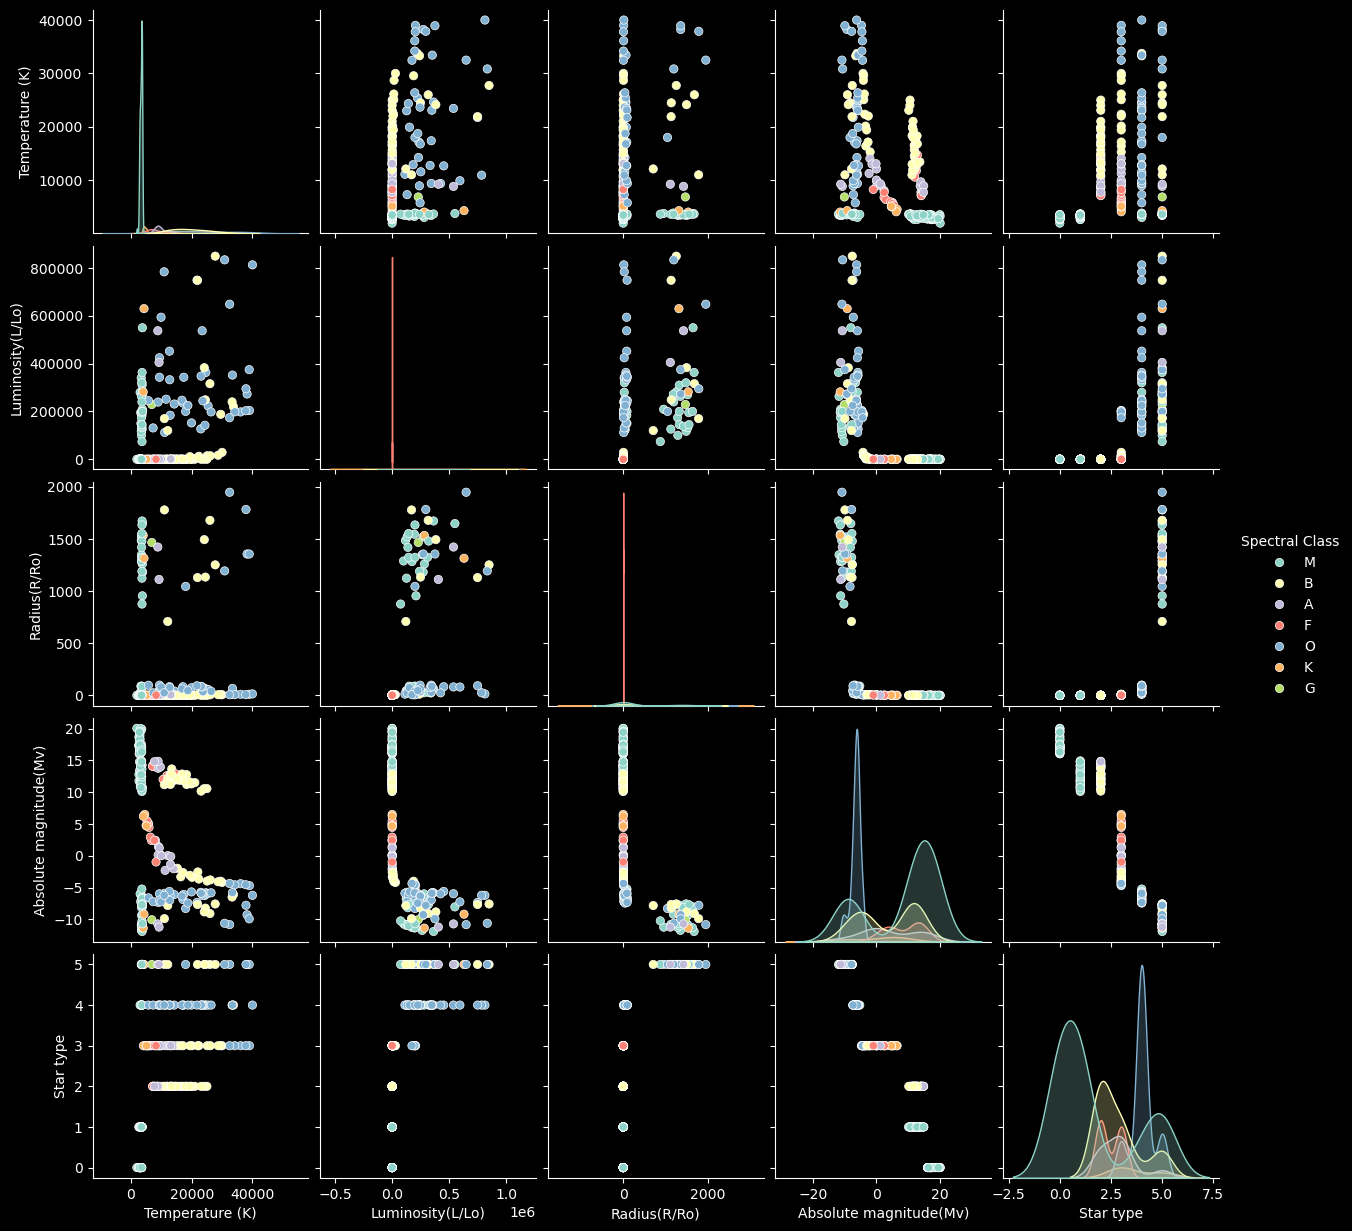

In [11]:
# Visualizing pair wise distributions between numeric columns

sns.pairplot(df, hue = 'Spectral Class')

save_plot('pair_plot_numerical_cols.png')
plt.show()

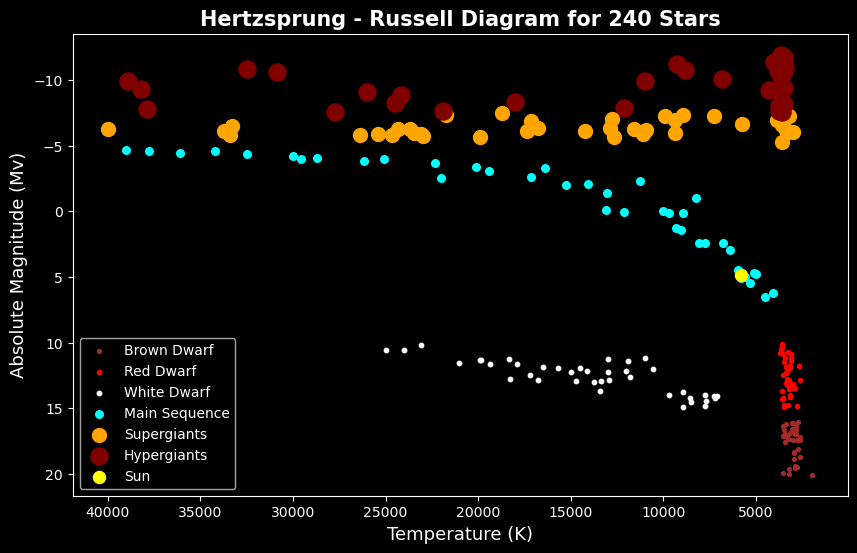

In [12]:
# Visualizing the relationship between Absolute magnitude (Mv)) and surface Temperature (K)

# Arrays to be used in the for loop
star_type = df['Star type'].values
temperature = df['Temperature (K)'].values
abs_mag = df['Absolute magnitude(Mv)'].values

plt.figure(figsize=(10,6))

axes = []
labels = set()

# Dictionaries made of key value pairs to get properties of star_type
star_types = {
    0: {'label': 'Brown Dwarf', 'color': 'brown', 'size': 30, 'marker': '.'},
    1: {'label': 'Red Dwarf', 'color': 'red', 'size': 35, 'marker': '.'},
    2: {'label': 'White Dwarf', 'color': 'white', 'size': 40, 'marker': '.'},
    3: {'label': 'Main Sequence', 'color': 'cyan', 'size': 30, 'marker': 'o'},
    4: {'label': 'Supergiants', 'color': 'orange', 'size': 100, 'marker': 'o'},
    5: {'label': 'Hypergiants', 'color': 'maroon', 'size': 150, 'marker': 'o'}
}

# Hertzsprung-Russell (HR) diagram
for i in range(len(star_type)):
    properties = star_types[star_type[i]]

    if properties['label'] not in labels:
        ax = plt.scatter(temperature[i], abs_mag[i],
                         s=properties['size'],
                         c=properties['color'],
                         marker=properties['marker'],
                         label=properties['label'])
        axes.append(ax)
        labels.add(properties['label'])
    else:
        plt.scatter(temperature[i], abs_mag[i],
                     s=properties['size'],
                     c=properties['color'],
                     marker=properties['marker'],
                     label=properties['label'])
        

# + Additional data for sun
ax_sun = plt.scatter(5778, 4.83, s=75, c="yellow", marker='o', label="Sun")
axes.append(ax_sun)
labels.add("Sun")

plt.legend(handles = axes)

# Invert the axes
plt.gca().invert_xaxis() 
plt.gca().invert_yaxis()

# Labels and Title
plt.title(f'Hertzsprung - Russell Diagram for {len(star_type)} Stars', fontsize = 15, weight='bold' )
plt.xlabel('Temperature (K)', fontsize = 13)
plt.ylabel('Absolute Magnitude (Mv)', fontsize = 13)

save_plot('HR_diagram_abs_mag_and_temp.png')
plt.show()